## Load Packages

In [2]:
import polars as pl
import pandas as pd
import random

random.seed(42)

## Loading Data

In [3]:
df = pl.read_csv(
    "data/combined_metadata_noncancer_removed.csv",
    schema_overrides={"group": pl.Utf8},   # <- dict of {col_name: dtype}
    infer_schema_length=0,                  # scan entire file for other cols
)

df_removed_samples = pl.read_csv(
    "data/samples_removed.csv",
    schema_overrides={"group": pl.Utf8},   # <- dict of {col_name: dtype}
    infer_schema_length=0,                  # scan entire file for other cols)
)

## Getting Random List of Samples From What we Think are all Cancerous

In [30]:
expression_data = df['experiment_accession']
expression_data

expression_list = expression_data.to_list()

list_to_check = random.sample(expression_list, 100)
df_check = pl.DataFrame({
    "accession": list_to_check,
    "label": [None] * len(list_to_check)  # placeholder column
})

df_check.write_csv("list_to_check.csv")

## Getting Random Sample from observations originally thought to be noncancerous

In [31]:
# df_removed_samples.head()

with open("../data/cancer_in_wrong_place.txt", "r") as f:
    content = f.read()

# If one accession per line
items = content.splitlines()
print(items)

# this is an example of things that are not tricky to figure out, we know why the cancers are being misclassified - so I'll filter out things that don't have

['ERR1331701', 'ERR1331676', 'ERR1331706', 'SRR10971334', 'SRR10971335', 'SRR10971336', 'SRR10971337', 'SRR10971338', 'SRR10971339', 'SRR10971340', 'SRR10971341', 'SRR10971342', 'SRR10971343', 'SRR10971344', 'SRR10971345', 'SRR10971346', 'SRR10971347', 'SRR10971348', 'SRR10971349', 'SRR10971350', 'SRR10971351', 'SRR10971352', 'SRR10971353', 'SRR10971354', 'SRR10971355', 'SRR10971356', 'SRR10971357', 'SRR10971358', 'SRR10971359', 'SRR10971360', 'SRR10971361', 'SRR10971362', 'SRR10971363', 'SRR10971364', 'SRR10971365', 'SRR10971366', 'SRR10971367', 'SRR10971368']


In [32]:
df.head()

experiment_alias,experiment_accession,title,study_name,sample_accession,library_name,library_strategy,library_source,library_selection,library_layout,platform_instrument_model,submitter_accession,submitter_id,organization_type,organization_name,study_accession,biosample,bioproject,organism_tax_id,organism_scientific_name,breed,dev_stage,sex,tissue,biosamplemodel,run_accession,run_total_spots,run_total_bases,run_size,run_load_done,run_is_public,run_has_tax_analysis,a_count,c_count,g_count,t_count,n_count,…,biosample_attributes,staining,processed_data_file_1,processed_data_file_2,processed_data_file_3,processed_data_file_4,processed_file_5,processed_file_6,confetti_clone,time_of_harvest,lgr5_status_of_injected_cells,cancer_status,subgroups,plate_number,target_gene,disease_induction,read_alignment_program,read_quantification_program,tumor_section,status_tissue,age_sacrifice,cells_loaded,gp33_status,repeat,hematopoietic_malignancy,facs_marker,tgf_beta_treatment,ena-first-public,ena-last-update,microbiome,trail_status,recipient,venus,arrayexpress-organismpart,arrayexpress-phenotype,arrayexpress-sex,arrayexpress-species
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""Lib2""","""SRX2358837""",null,null,"""SRS1807531""","""Lib2""","""RNA-Seq""","""TRANSCRIPTOMIC""","""RANDOM""","""SINGLE""",null,"""SRA496069""","""SUB2109767""","""institute""","""AAU""","""SRP093520""",null,"""PRJNA353983""","""9915""","""Bos indicus""","""zebu""","""not collected""","""neuter""","""horn tissue""","""Model organism or animal""","""SRR5034190""","""909364.0""","""363882457.0""","""236633098.0""","""True""","""True""","""1.0""","""90507536.0""","""90635597.0""","""91335407.0""","""91268959.0""","""134958.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""HC_30""","""SRX4947457""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989751""","""HC_30""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273298""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Myxomatous_12""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121155""","""3671359.0""","""1138556106.0""","""719166371.0""","""True""","""True""","""1.0""","""286730289.0""","""284335813.0""","""283525767.0""","""283964235.0""","""2.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""HC_29""","""SRX4947456""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989750""","""HC_29""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273297""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Myxomatous_11""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121156""","""4806102.0""","""1571499249.0""","""1023719372.0""","""True""","""True""","""1.0""","""386343262.0""","""401887678.0""","""399494765.0""","""383773540.0""","""4.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""HC_26""","""SRX4947455""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989749""","""HC_26""","""RNA-Seq""","""TRANSCRIPT

In [33]:
df.columns

['experiment_alias',
 'experiment_accession',
 'title',
 'study_name',
 'sample_accession',
 'library_name',
 'library_strategy',
 'library_source',
 'library_selection',
 'library_layout',
 'platform_instrument_model',
 'submitter_accession',
 'submitter_id',
 'organization_type',
 'organization_name',
 'study_accession',
 'biosample',
 'bioproject',
 'organism_tax_id',
 'organism_scientific_name',
 'breed',
 'dev_stage',
 'sex',
 'tissue',
 'biosamplemodel',
 'run_accession',
 'run_total_spots',
 'run_total_bases',
 'run_size',
 'run_load_done',
 'run_is_public',
 'run_has_tax_analysis',
 'a_count',
 'c_count',
 'g_count',
 't_count',
 'n_count',
 'cancer_type',
 'strain',
 'isolate',
 'cultivar',
 'ecotype',
 'age',
 'cell_line',
 'disease',
 'single-cell/bulk',
 'library_construction_protocol',
 'submitter_title',
 'source_name',
 'animal_id',
 'animal_type',
 'block',
 'geo_loc_name',
 'collection_date',
 'genotype',
 'development_stage',
 'collected_by',
 'storage_conditions',
 '

## Performing regex/ making a score

In [34]:
# Choose text columns that exist in your DF
TEXT_COLS = [
    "title","study_name","library_name","library_strategy","library_source",
    "library_selection","tissue","dev_stage","breed","organization_name",
    "organism_scientific_name","submitter_id","biosample","bioproject",
    "experiment_alias","experiment_accession","study_accession",
    "sample_accession","platform_instrument_model","sex"
]
TEXT_COLS = [c for c in TEXT_COLS if c in df.columns]

def norm_expr(col):
    return (
        pl.col(col).cast(pl.Utf8).fill_null("")
        .str.to_lowercase()
        .str.replace_all(r"[_/|]", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()          # <-- use this instead of .str.strip()
    )

exprs = [norm_expr(c) for c in TEXT_COLS]
df = df.with_columns(
    pl.concat_str(exprs, separator=" ").alias("__text") if exprs else pl.lit("").alias("__text")
)

# Regex lists
CANCER_POS = r"(?:\bcancers?\b|\btumou?rs?\b|\bmalignan(?:t|cy)\b|\bcarcinomas?\b|\bneoplasms?\b|\bmetasta(?:s|t)es?\b|\badenocarcinomas?\b|\bsarcomas?\b|\bleukemi(?:a|as)\b|\blymphom(?:a|as)\b|\bglioblastomas?\b|\bmelanomas?\b|\boncolog(?:y|ic|ical)\b)"
STRONG_POS = r"(?:\bcancers?\b|\btumou?rs?\b|\bcarcinomas?\b|\bmalignan(?:t|cy)\b|\bneoplasms?\b|\bmetasta(?:s|t)es?\b)"
CANCER_NEG = r"(?:\bnormal\b|\bhealthy\b|\bctrl\b|\badjacent normal\b|\bnon[-\s]?tumou?r(?:al)?\b|\bbenign\b|\bnon[-\s]?cancer(?:ous)?\b|\bsham\b|\bunaffected\b)"
NEG_SCOPED = r"(?:\b(?:no|not|without|free of)\s+(?:any\s+)?(?:cancer|tumou?r|carcinoma|malignancy|neoplasm)s?\b)"
ONCO_TRAPS = r"(?:\boncophora\b|\boncorhynchus\b|\boncotic\b|\boncomodulin\b)"

# Define your hit expressions once
pos_hit     = pl.col("__text").str.contains(CANCER_POS)
strong_pos  = pl.col("__text").str.contains(STRONG_POS)
neg_hit     = pl.col("__text").str.contains(CANCER_NEG) | pl.col("__text").str.contains(NEG_SCOPED)
onco_traps  = pl.col("__text").str.contains(ONCO_TRAPS)

# Reuse a single score expression
score_expr = (
    pos_hit.cast(pl.Int8)
    + strong_pos.cast(pl.Int8)
    - (neg_hit.cast(pl.Int8) * 2)
    - (onco_traps.cast(pl.Int8) * 2)
)

df = df.with_columns([
    score_expr.alias("cancer_score"),
    pl.when(score_expr >= 1).then(pl.lit(True))
     .when(score_expr <= -1).then(pl.lit(False))
     .otherwise(None)
     .alias("predicted_cancer"),

    # Build "explain" with concat_str instead of chained .str.concat(...)
    pl.concat_str(
        [
            pl.when(onco_traps).then(pl.lit("onco-trap")).otherwise(pl.lit("")),
            pl.when(neg_hit).then(pl.lit(",neg-context")).otherwise(pl.lit("")),
            pl.when(strong_pos).then(pl.lit(",strong-cancer-term"))
             .otherwise(pl.when(pos_hit).then(pl.lit(",weak-cancer-term")).otherwise(pl.lit(""))),
        ],
        separator=""
    )
    .str.replace_all(r"^,", "")
    .str.replace_all(r",$", "")
    .alias("explain"),
])

# Example: rows predicted non-cancer (unchanged)
non_cancer_df = df.filter(
    (pl.col("predicted_cancer") == False) | ((pl.col("predicted_cancer").is_null()) & neg_hit)
)


In [35]:
df

# cancer* could be cancer or unrelated - pick up organization names with cqncer in name but no relation to cancer

# check the bioprojects w/ PR ... probably PRJ

# some accuracy score/tests

experiment_alias,experiment_accession,title,study_name,sample_accession,library_name,library_strategy,library_source,library_selection,library_layout,platform_instrument_model,submitter_accession,submitter_id,organization_type,organization_name,study_accession,biosample,bioproject,organism_tax_id,organism_scientific_name,breed,dev_stage,sex,tissue,biosamplemodel,run_accession,run_total_spots,run_total_bases,run_size,run_load_done,run_is_public,run_has_tax_analysis,a_count,c_count,g_count,t_count,n_count,…,processed_data_file_3,processed_data_file_4,processed_file_5,processed_file_6,confetti_clone,time_of_harvest,lgr5_status_of_injected_cells,cancer_status,subgroups,plate_number,target_gene,disease_induction,read_alignment_program,read_quantification_program,tumor_section,status_tissue,age_sacrifice,cells_loaded,gp33_status,repeat,hematopoietic_malignancy,facs_marker,tgf_beta_treatment,ena-first-public,ena-last-update,microbiome,trail_status,recipient,venus,arrayexpress-organismpart,arrayexpress-phenotype,arrayexpress-sex,arrayexpress-species,__text,cancer_score,predicted_cancer,explain
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i8,bool,str
"""Lib2""","""SRX2358837""",null,null,"""SRS1807531""","""Lib2""","""RNA-Seq""","""TRANSCRIPTOMIC""","""RANDOM""","""SINGLE""",null,"""SRA496069""","""SUB2109767""","""institute""","""AAU""","""SRP093520""",null,"""PRJNA353983""","""9915""","""Bos indicus""","""zebu""","""not collected""","""neuter""","""horn tissue""","""Model organism or animal""","""SRR5034190""","""909364.0""","""363882457.0""","""236633098.0""","""True""","""True""","""1.0""","""90507536.0""","""90635597.0""","""91335407.0""","""91268959.0""","""134958.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,""" lib2 rna-seq transcriptomic …",0,null,""""""
"""HC_30""","""SRX4947457""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989751""","""HC_30""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273298""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Myxomatous_12""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121155""","""3671359.0""","""1138556106.0""","""719166371.0""","""True""","""True""","""1.0""","""286730289.0""","""284335813.0""","""283525767.0""","""283964235.0""","""2.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""transcriptome of bos indicus:b…",2,true,"""strong-cancer-term"""
"""HC_29""","""SRX4947456""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989750""","""HC_29""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273297""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Myxomatous_11""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121156""","""4806102.0""","""1571499249.0""","""1023719372.0""","""True""","""True""","""1.0""","""386343262.0""","""401887678.0""","""399494765.0""","""383773540.0""","""4.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""transcriptome of bos indicus:b…",2,true,"""strong-cancer-term"""
"""HC_26""","""SRX4947455""","""Transcriptome of Bos indicus:

In [36]:
df.select([
    "sample_accession",
    "study_accession",
    "tissue",
    "library_construction_protocol",
    "source_name",
    "cancer_score"
])

sample_accession,study_accession,tissue,library_construction_protocol,source_name,cancer_score
str,str,str,str,str,i8
"""SRS1807531""","""SRP093520""","""horn tissue""",null,null,0
"""SRS3989751""","""SRP167079""","""Horn epithelial""",null,null,2
"""SRS3989750""","""SRP167079""","""Horn epithelial""",null,null,2
"""SRS3989749""","""SRP167079""","""Horn epithelial""",null,null,2
"""SRS3989754""","""SRP167079""","""Horn epithelial""",null,null,2
…,…,…,…,…,…
"""SRS5276478""","""SRP218524""","""Cell line nan Cell line nan""",null,null,1
"""SRS5276477""","""SRP218524""","""Cell line nan Cell line nan""",null,null,1
"""SRS5276478""","""SRP218524""","""Cell line nan Cell line nan""",null,null,1


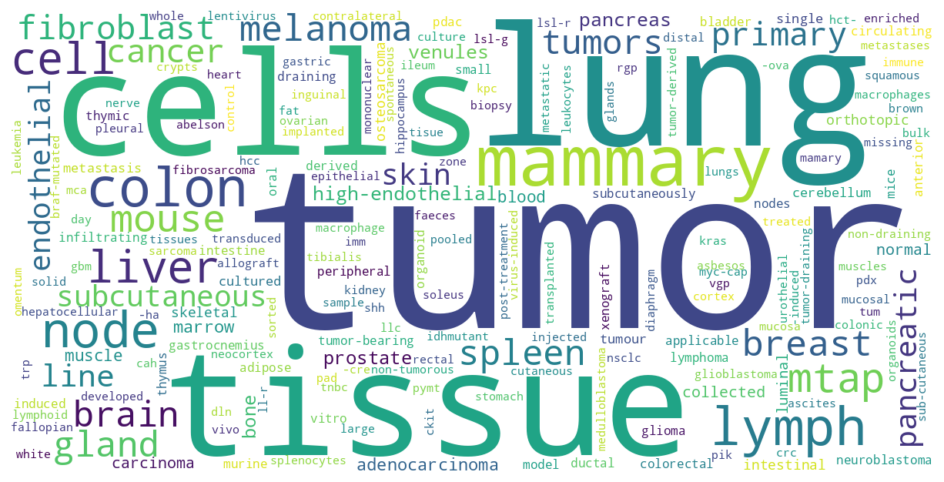

In [37]:
from wordcloud import WordCloud, STOPWORDS
import polars as pl
import matplotlib.pyplot as plt

# Tokenize with Polars, count words
words = (
    df.select(
        pl.col("tissue")
          .cast(pl.Utf8)
          .fill_null("")
          .str.to_lowercase()
          .str.replace_all(r"\b(nan|none)\b", "")
          .str.replace_all(r"[^a-z\s-]", " ")
          .str.replace_all(r"\s+", " ")
          .str.strip_chars()              # <- Polars uses strip_chars, not strip
          .str.split(" ")
          .alias("tissue")                # make sure the column is named for later steps
    )
    .explode("tissue")
    .filter(pl.col("tissue") != "")
    .group_by("tissue")                  # .groupby(...) also works; this is the modern name
    .len()
    .rename({"len": "count"})
    .sort("count", descending=True)
)

# Convert to dict and drop stopwords/short tokens
stops = set(STOPWORDS) | {"nan", "none"}
freqs = {w: int(c) for w, c in zip(words["tissue"].to_list(), words["count"].to_list())
         if w not in stops and len(w) > 2}

wc = WordCloud(width=1200, height=600, background_color="white", collocations=False)
wc = wc.generate_from_frequencies(freqs)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()
# wc.to_file("tissue_wordcloud.png")


In [38]:
non_cancer_df

experiment_alias,experiment_accession,title,study_name,sample_accession,library_name,library_strategy,library_source,library_selection,library_layout,platform_instrument_model,submitter_accession,submitter_id,organization_type,organization_name,study_accession,biosample,bioproject,organism_tax_id,organism_scientific_name,breed,dev_stage,sex,tissue,biosamplemodel,run_accession,run_total_spots,run_total_bases,run_size,run_load_done,run_is_public,run_has_tax_analysis,a_count,c_count,g_count,t_count,n_count,…,processed_data_file_3,processed_data_file_4,processed_file_5,processed_file_6,confetti_clone,time_of_harvest,lgr5_status_of_injected_cells,cancer_status,subgroups,plate_number,target_gene,disease_induction,read_alignment_program,read_quantification_program,tumor_section,status_tissue,age_sacrifice,cells_loaded,gp33_status,repeat,hematopoietic_malignancy,facs_marker,tgf_beta_treatment,ena-first-public,ena-last-update,microbiome,trail_status,recipient,venus,arrayexpress-organismpart,arrayexpress-phenotype,arrayexpress-sex,arrayexpress-species,__text,cancer_score,predicted_cancer,explain
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i8,bool,str
"""HN_05""","""SRX4947437""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989732""","""HN_05""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273273""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Normal_5""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121175""","""4185024.0""","""1364073713.0""","""809665392.0""","""True""","""True""","""1.0""","""343810532.0""","""339921123.0""","""340441501.0""","""339900557.0""","""0.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""transcriptome of bos indicus:b…",0,null,"""neg-context,strong-cancer-term"""
"""HN_01""","""SRX4947433""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989728""","""HN_01""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273269""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Normal_1""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121179""","""3307344.0""","""1137880294.0""","""665972560.0""","""True""","""True""","""1.0""","""292039389.0""","""277758017.0""","""278194815.0""","""289888073.0""","""0.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""transcriptome of bos indicus:b…",0,null,"""neg-context,strong-cancer-term"""
"""HN_02""","""SRX4947432""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989727""","""HN_02""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273270""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Normal_2""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121180""","""3832312.0""","""1320456326.0""","""781337901.0""","""True""","""True""","""1.0""","""342291385.0""","""319380214.0""","""319137687.0""","""339647040.0""","""0.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null

In [39]:
non_cancer_df.select([
    "sample_accession",
    "study_accession",
    "tissue",
    "library_construction_protocol",
    "source_name",
    "cancer_score",
    "run_accession"
])


sample_accession,study_accession,tissue,library_construction_protocol,source_name,cancer_score,run_accession
str,str,str,str,str,i8,str
"""SRS3989732""","""SRP167079""","""Horn epithelial""",null,null,0,"""SRR8121175"""
"""SRS3989728""","""SRP167079""","""Horn epithelial""",null,null,0,"""SRR8121179"""
"""SRS3989727""","""SRP167079""","""Horn epithelial""",null,null,0,"""SRR8121180"""
"""SRS3989753""","""SRP167079""","""Horn epithelial""",null,null,0,"""SRR8121181"""
"""SRS3989726""","""SRP167079""","""Horn epithelial""",null,null,0,"""SRR8121182"""
…,…,…,…,…,…,…
"""SRS5130129""","""SRP215797""","""tumor nan tumor nan""",null,null,0,"""SRR9722461"""
"""SRS5130128""","""SRP215797""","""tumor nan tumor nan""",null,null,0,"""SRR9722462"""
"""SRS5238209""","""SRP217843""","""tumor nan tumor nan""","""Tumor tissues were harvested i…","""xenograft tumor tissues""",0,"""SRR9931562"""


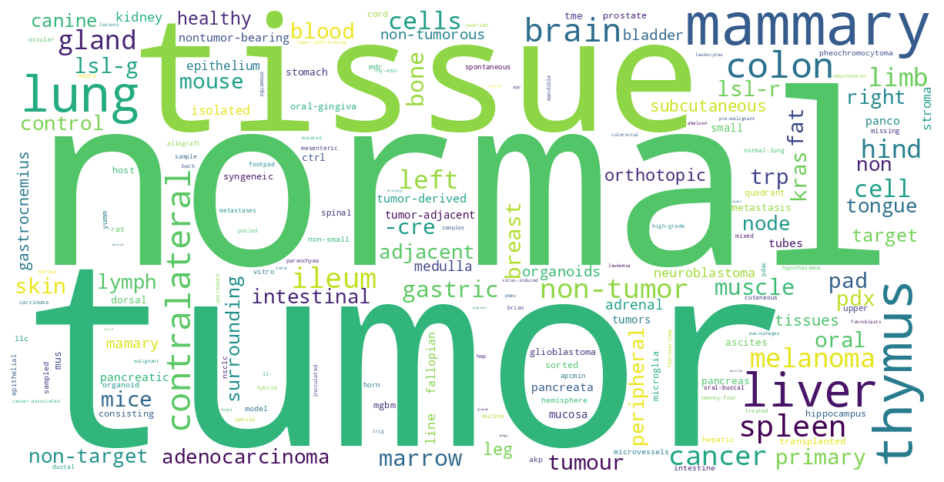

In [40]:
# Tokenize with Polars, count words
words = (
    non_cancer_df.select(
        pl.col("tissue")
          .cast(pl.Utf8)
          .fill_null("")
          .str.to_lowercase()
          .str.replace_all(r"\b(nan|none)\b", "")
          .str.replace_all(r"[^a-z\s-]", " ")
          .str.replace_all(r"\s+", " ")
          .str.strip_chars()              # <- Polars uses strip_chars, not strip
          .str.split(" ")
          .alias("tissue")                # make sure the column is named for later steps
    )
    .explode("tissue")
    .filter(pl.col("tissue") != "")
    .group_by("tissue")                  # .groupby(...) also works; this is the modern name
    .len()
    .rename({"len": "count"})
    .sort("count", descending=True)
)

# Convert to dict and drop stopwords/short tokens
stops = set(STOPWORDS) | {"nan", "none"}
freqs = {w: int(c) for w, c in zip(words["tissue"].to_list(), words["count"].to_list())
         if w not in stops and len(w) > 2}

wc = WordCloud(width=1200, height=600, background_color="white", collocations=False)
wc = wc.generate_from_frequencies(freqs)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()
# wc.to_file("tissue_wordcloud.png")


In [41]:
df.filter(pl.col('tissue').str.contains_any("tumor"))

/var/folders/3w/q_m3rh1s5xv5bh0kfpcqmd9r0000gn/T/ipykernel_34697/1814802375.py:1: DeprecationWarning: `str.contains_any` with a flat string datatype is deprecated.
Please use `implode` to return to previous behavior.
See https://github.com/pola-rs/polars/issues/22149 for more information.
  df.filter(pl.col('tissue').str.contains_any("tumor"))


experiment_alias,experiment_accession,title,study_name,sample_accession,library_name,library_strategy,library_source,library_selection,library_layout,platform_instrument_model,submitter_accession,submitter_id,organization_type,organization_name,study_accession,biosample,bioproject,organism_tax_id,organism_scientific_name,breed,dev_stage,sex,tissue,biosamplemodel,run_accession,run_total_spots,run_total_bases,run_size,run_load_done,run_is_public,run_has_tax_analysis,a_count,c_count,g_count,t_count,n_count,…,processed_data_file_3,processed_data_file_4,processed_file_5,processed_file_6,confetti_clone,time_of_harvest,lgr5_status_of_injected_cells,cancer_status,subgroups,plate_number,target_gene,disease_induction,read_alignment_program,read_quantification_program,tumor_section,status_tissue,age_sacrifice,cells_loaded,gp33_status,repeat,hematopoietic_malignancy,facs_marker,tgf_beta_treatment,ena-first-public,ena-last-update,microbiome,trail_status,recipient,venus,arrayexpress-organismpart,arrayexpress-phenotype,arrayexpress-sex,arrayexpress-species,__text,cancer_score,predicted_cancer,explain
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i8,bool,str
"""GSM4433115""","""SRX8003630""","""GSM4433115: 1033; Canis lupus …",null,"""SRS6377608""",null,"""RNA-Seq""","""TRANSCRIPTOMIC""","""cDNA""","""PAIRED""","""Illumina HiSeq 2000""","""SRA1059426""","""nan GEO: GSE147550 nan nan GEO…","""center""","""NCBI""","""SRP254052""","""GSM4433115""","""PRJNA615229""","""9615""","""Canis lupus familiaris""","""Boxer""",null,"""nan nan nan nan nan nan""","""bone tumor""",null,"""SRR11425266""","""29869545.0""","""2986954500.0""","""2092577260.0""","""True""","""True""","""1.0""","""716809836.0""","""778426942.0""","""763322992.0""","""721435644.0""","""6959086.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""gsm4433115: 1033; canis lupus …",2,true,"""strong-cancer-term"""
"""GSM4433116""","""SRX8003631""","""GSM4433116: 1091; Canis lupus …",null,"""SRS6377609""",null,"""RNA-Seq""","""TRANSCRIPTOMIC""","""cDNA""","""PAIRED""","""Illumina HiSeq 2000""","""SRA1059426""","""nan GEO: GSE147550 nan nan GEO…","""center""","""NCBI""","""SRP254052""","""GSM4433116""","""PRJNA615229""","""9615""","""Canis lupus familiaris""","""Leonberger""",null,"""nan nan nan nan nan nan""","""bone tumor""",null,"""SRR11425267""","""20783422.0""","""2078342200.0""","""1462389163.0""","""True""","""True""","""1.0""","""500984915.0""","""538886347.0""","""529833836.0""","""503805439.0""","""4831663.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""gsm4433116: 1091; canis lupus …",2,true,"""strong-cancer-term"""
"""GSM4433117""","""SRX8003632""","""GSM4433117: 0320; Canis lupus …",null,"""SRS6377610""",null,"""RNA-Seq""","""TRANSCRIPTOMIC""","""cDNA""","""PAIRED""","""Illumina HiSeq 2000""","""SRA1059426""","""nan GEO: GSE147550 nan nan GEO…","""center""","""NCBI""","""SRP254052""","""GSM4433117""","""PRJNA615229""","""9615""","""Canis lupus familiaris""","""Mixed""",null,"""nan nan nan nan nan nan""","""bone tumor""",null,"""SRR11425268""","""17035193.0""","""1703519300.0""","""1195909499.0""","""True""","""True""","""1.0""","""421610360.0""","""429839981.0""","""423767695.0""","""424367382.0""","""3933882.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""gsm4433117: 0320; canis lupus …",2,true,"""strong-cancer-term"""
"""GSM4433118""","""SRX8003633""","""GSM4433118: 0460

In [42]:
# non_cancer_df.filter(pl.col('tissue').str.contains_any("tumor")).select("sco")

In [43]:
non_cancer_df

experiment_alias,experiment_accession,title,study_name,sample_accession,library_name,library_strategy,library_source,library_selection,library_layout,platform_instrument_model,submitter_accession,submitter_id,organization_type,organization_name,study_accession,biosample,bioproject,organism_tax_id,organism_scientific_name,breed,dev_stage,sex,tissue,biosamplemodel,run_accession,run_total_spots,run_total_bases,run_size,run_load_done,run_is_public,run_has_tax_analysis,a_count,c_count,g_count,t_count,n_count,…,processed_data_file_3,processed_data_file_4,processed_file_5,processed_file_6,confetti_clone,time_of_harvest,lgr5_status_of_injected_cells,cancer_status,subgroups,plate_number,target_gene,disease_induction,read_alignment_program,read_quantification_program,tumor_section,status_tissue,age_sacrifice,cells_loaded,gp33_status,repeat,hematopoietic_malignancy,facs_marker,tgf_beta_treatment,ena-first-public,ena-last-update,microbiome,trail_status,recipient,venus,arrayexpress-organismpart,arrayexpress-phenotype,arrayexpress-sex,arrayexpress-species,__text,cancer_score,predicted_cancer,explain
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i8,bool,str
"""HN_05""","""SRX4947437""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989732""","""HN_05""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273273""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Normal_5""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121175""","""4185024.0""","""1364073713.0""","""809665392.0""","""True""","""True""","""1.0""","""343810532.0""","""339921123.0""","""340441501.0""","""339900557.0""","""0.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""transcriptome of bos indicus:b…",0,null,"""neg-context,strong-cancer-term"""
"""HN_01""","""SRX4947433""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989728""","""HN_01""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273269""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Normal_1""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121179""","""3307344.0""","""1137880294.0""","""665972560.0""","""True""","""True""","""1.0""","""292039389.0""","""277758017.0""","""278194815.0""","""289888073.0""","""0.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""transcriptome of bos indicus:b…",0,null,"""neg-context,strong-cancer-term"""
"""HN_02""","""SRX4947432""","""Transcriptome of Bos indicus:b…","""Illumina TruSeq mRNA Strensed …","""SRS3989727""","""HN_02""","""RNA-Seq""","""TRANSCRIPTOMIC""","""PCR""","""PAIRED""","""Illumina MiSeq""","""SRA798653""","""SUB4680127""","""institute""","""Anand Agricultural University""","""SRP167079""","""SAMN10273270""","""PRJNA497667""","""9915""","""Bos indicus""","""Kankrej""","""Normal_2""","""male""","""Horn epithelial""","""Model organism or animal""","""SRR8121180""","""3832312.0""","""1320456326.0""","""781337901.0""","""True""","""True""","""1.0""","""342291385.0""","""319380214.0""","""319137687.0""","""339647040.0""","""0.0""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null

In [70]:
subset_df = df.join(non_cancer_df, on=df.columns, how="anti")

In [71]:
# list the columns you want
keep_cols = [
    "title",
    "single-cell/bulk",
    "tissue",
    "disease",
    "experiment_accession",
    "bioproject",
    "biosample",
    "sample_accession",
    "study_accession",
    "library_construction_protocol",
    "source_name",
    "cancer_score",
    "run_accession",
    "cancer_type"
]

# subset dataframe to just these columns
subset_df = subset_df.select(keep_cols)

In [72]:
subset_df

title,single-cell/bulk,tissue,disease,experiment_accession,bioproject,biosample,sample_accession,study_accession,library_construction_protocol,source_name,cancer_score,run_accession,cancer_type
str,str,str,str,str,str,str,str,str,str,str,i8,str,str
null,"""bulk""","""horn tissue""","""horn cancer""","""SRX2358837""","""PRJNA353983""",null,"""SRS1807531""","""SRP093520""",null,null,0,"""SRR5034190""","""cancer*"""
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947457""","""PRJNA497667""","""SAMN10273298""","""SRS3989751""","""SRP167079""",null,null,2,"""SRR8121155""","""squamous cell carcinoma"""
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947456""","""PRJNA497667""","""SAMN10273297""","""SRS3989750""","""SRP167079""",null,null,2,"""SRR8121156""","""squamous cell carcinoma"""
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947455""","""PRJNA497667""","""SAMN10273294""","""SRS3989749""","""SRP167079""",null,null,2,"""SRR8121157""","""squamous cell carcinoma"""
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947454""","""PRJNA497667""","""SAMN10273293""","""SRS3989754""","""SRP167079""",null,null,2,"""SRR8121158""","""squamous cell carcinoma"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""bulk RNA-seq of B16F10 melano…","""bulk""","""Cell line nan Cell line nan""",null,"""SRX6724342""","""PRJNA560483""",null,"""SRS5276478""","""SRP218524""",null,null,1,"""SRR9983259""","""melanoma"""
"""bulk RNA-seq of B16F0 melanom…","""bulk""","""Cell line nan Cell line nan""",null,"""SRX6724341""","""PRJNA560483""",null,"""SRS5276477""","""SRP218524""",null,null,1,"""SRR9983260""","""melanoma"""
"""single cell RNA-seq of B16F10 …","""single-cell""","""Cell line nan Cell line nan""",null,"""SRX6724340""","""PRJNA560483""",null,"""SRS5276478""","""SRP218524""",null,null,1,"""SRR9983261""","""melanoma"""


In [73]:
non_cancer_df = non_cancer_df.select(keep_cols)
non_cancer_df

title,single-cell/bulk,tissue,disease,experiment_accession,bioproject,biosample,sample_accession,study_accession,library_construction_protocol,source_name,cancer_score,run_accession,cancer_type
str,str,str,str,str,str,str,str,str,str,str,i8,str,str
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947437""","""PRJNA497667""","""SAMN10273273""","""SRS3989732""","""SRP167079""",null,null,0,"""SRR8121175""","""squamous cell carcinoma"""
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947433""","""PRJNA497667""","""SAMN10273269""","""SRS3989728""","""SRP167079""",null,null,0,"""SRR8121179""","""squamous cell carcinoma"""
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947432""","""PRJNA497667""","""SAMN10273270""","""SRS3989727""","""SRP167079""",null,null,0,"""SRR8121180""","""squamous cell carcinoma"""
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947431""","""PRJNA497667""","""SAMN10273271""","""SRS3989753""","""SRP167079""",null,null,0,"""SRR8121181""","""squamous cell carcinoma"""
"""Transcriptome of Bos indicus:b…","""bulk""","""Horn epithelial""",null,"""SRX4947430""","""PRJNA497667""","""SAMN10273272""","""SRS3989726""","""SRP167079""",null,null,0,"""SRR8121182""","""squamous cell carcinoma"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ctrl mtx2 male TIDC""","""bulk""","""tumor nan tumor nan""",null,"""SRX6480011""","""PRJNA555789""",null,"""SRS5130129""","""SRP215797""",null,null,0,"""SRR9722461""","""tumor*"""
"""ctrl mtx1 male TIDC""","""bulk""","""tumor nan tumor nan""",null,"""SRX6480010""","""PRJNA555789""",null,"""SRS5130128""","""SRP215797""",null,null,0,"""SRR9722462""","""tumor*"""
"""GSM4018782: MiaPaca-2_Ctrl 1; …","""bulk""","""tumor nan tumor nan""",null,"""SRX6680419""","""PRJNA559355""","""GSM4018782""","""SRS5238209""","""SRP217843""","""Tumor tissues were harvested i…","""xenograft tumor tissues""",0,"""SRR9931562""","""tumor*"""


In [79]:
SEED = 42

# sample 200 rows from each DataFrame
sample_subset = subset_df.sample(n=200, shuffle=True, seed=SEED).with_columns(
    pl.lit(0).alias("is_cancer")   # cancer group
)
sample_non_cancer = non_cancer_df.sample(n=200, shuffle=True, seed=SEED).with_columns(
    pl.lit(1).alias("is_cancer")   # non-cancer group
)

# combine them
combined_df = pl.concat([sample_subset, sample_non_cancer])

# shuffle the combined dataset
combined_df = combined_df.sample(fraction=1.0, shuffle=True, seed=SEED)

print(combined_df.shape)
print(combined_df.head())

(400, 15)
shape: (5, 15)
┌────────────┬───────────┬───────────┬─────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ title      ┆ single-ce ┆ tissue    ┆ disease ┆ … ┆ cancer_sc ┆ run_acces ┆ cancer_ty ┆ is_cancer │
│ ---        ┆ ll/bulk   ┆ ---       ┆ ---     ┆   ┆ ore       ┆ sion      ┆ pe        ┆ ---       │
│ str        ┆ ---       ┆ str       ┆ str     ┆   ┆ ---       ┆ ---       ┆ ---       ┆ i32       │
│            ┆ str       ┆           ┆         ┆   ┆ i8        ┆ str       ┆ str       ┆           │
╞════════════╪═══════════╪═══════════╪═════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ GSM5220969 ┆ bulk      ┆ lung      ┆ null    ┆ … ┆ 0         ┆ SRR141186 ┆ nan adeno ┆ 0         │
│ : mice_NSD ┆           ┆ tumor     ┆         ┆   ┆           ┆ 70        ┆ carcinoma ┆           │
│ 2EK2_Ctrl_ ┆           ┆           ┆         ┆   ┆           ┆           ┆ nan       ┆           │
│ …          ┆           ┆           ┆         ┆   ┆           ┆  

In [80]:
combined_df.write_csv("manual_verification_dataset.csv")